In [27]:
#importing libraries 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import ast
import seaborn as sns
from datasets import load_dataset
from matplotlib.lines import Line2D


#Loading the data 
dataset=load_dataset("lukebarousse/data_jobs")
df=dataset["train"].to_pandas()
df_work=df.copy()


#Data cleanup 
# Converting job_posted_date to datetime object 
df_work["job_posted_date"]=pd.to_datetime(df_work["job_posted_date"])
# Converting job_skills to list 
df_work["job_skills"]=df_work.job_skills.apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## Handling Missing Salary Data

As the primary focus of this analysis is annual salary, missing values in the `salary_year_avg` column were addressed before proceeding.

Data is cleaned by converting  `salary_hour_avg` to yearly salary in column `salary_year_avg`. This conversion assumes a full-time schedule of 40 working hours per week and 52 working weeks per year (2,080 hours annually).

Records with missing values in both `salary_year_avg` and `salary_hour_avg` were removed from the dataset, as insufficient information was available to estimate annual compensation. 

In [28]:
def convert_hour_to_year(row):
    if pd.isna(row["salary_year_avg"]) and  pd.notna(row["salary_hour_avg"]):
        row["salary_year_avg"]=row["salary_hour_avg"]*40*52
        return row["salary_year_avg"]
    else:
        return row["salary_year_avg"]

In [29]:
df_work["salary_year_avg"]=df_work.apply(convert_hour_to_year, axis=1)

In [30]:
df_work=df_work[pd.notna(df_work["salary_year_avg"])==True]

In [31]:
df_work['job_country']=df_work.job_country.str.strip()

In [32]:
#Inspection 
top_10_countries=df_work.job_country.value_counts().head(10).index

## To Plot  

Distribution of average salary of each jobb title in 10 countries with most data available


In [33]:
filtered_data=df_work[df_work['job_country'].isin(top_10_countries)]
filtered_data

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
43,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,"Texas, United States",2023-09-13 13:06:55,True,False,United States,hour,202800.0,97.5,Phaxis,"[sql, sql server]","{'databases': ['sql server'], 'programming': [..."
51,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,"Illinois, United States",2023-06-21 13:09:39,False,False,United States,hour,150800.0,72.5,Aditi Consulting,"[python, java, aws, databricks, spark]","{'cloud': ['aws', 'databricks'], 'libraries': ..."
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,NaN,Intelletec,"[mongodb, mongodb, python, r, sql, mysql, mari...","{'analyst_tools': ['tableau'], 'cloud': ['orac..."
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"[go, python, r, sql, oracle, windows, alteryx,...","{'analyst_tools': ['alteryx', 'power bi', 'tab..."
785641,Data Engineer,Data Engineer,"New York, NY",via Dice,Full-time,False,Georgia,2023-01-04 16:36:07,True,False,United States,year,150000.0,NaN,"Engage Partners, Inc.",NaN,NaN
785648,Data Scientist,Director Data Scientist - Commercial Platforms...,"Pleasant Hill, CA",via Ai-Jobs.net,Full-time,False,"California, United States",2023-04-12 06:02:51,False,True,United States,year,221875.0,NaN,84.51°,"[python, azure, snowflake, spark]","{'cloud': ['azure', 'snowflake'], 'libraries':..."
785682,Data Scientist,Data Scientist für datengetriebene Entwicklung...,"Reutlingen, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-04 06:16:08,False,False,Germany,year,157500.0,NaN,Bosch Group,"[python, hadoop, spark, airflow, kubernetes]","{'libraries': ['hadoop', 'spark', 'airflow'], ..."


In [34]:
salary_pivot = filtered_data.pivot_table(index="job_title_short", columns="job_country", values="salary_year_avg", aggfunc="mean", fill_value=0).round(2)
salary_pivot

job_country,Australia,Canada,France,Germany,India,Poland,Spain,Sudan,United Kingdom,United States
job_title_short,,,,,,,,,,
Business Analyst,61342.86,84595.38,81158.33,75296.15,76204.10,87506.25,110780.00,80758.92,49560.00,94041.60
Cloud Engineer,64400.00,130300.00,105968.00,119607.14,0.00,101333.33,90351.00,81694.42,0.00,113852.18
Data Analyst,73537.50,83032.47,78999.47,97750.52,97691.68,87505.29,88542.94,86843.88,89325.84,87451.77
Data Engineer,74313.84,119193.65,115738.14,130275.90,122892.91,117805.91,116776.64,127036.00,115585.11,129043.88
Data Scientist,108899.40,121757.01,97506.64,115706.43,117491.82,120457.50,91209.93,121276.44,110250.93,128470.64
Machine Learning Engineer,98092.90,149013.31,91124.06,113882.82,111372.57,111711.41,112953.44,150426.96,139564.43,143107.96
Senior Data Analyst,47626.67,117289.29,104299.29,99556.80,105740.59,107712.78,107536.11,105076.85,107314.38,111578.10
Senior Data Engineer,88576.40,120044.55,135671.53,127552.81,132148.63,99319.22,123543.91,145169.97,135584.02,146604.02
Senior Data Scientist,124385.71,133578.82,133270.00,148728.57,126035.79,132548.17,138864.86,145317.54,129399.23,150588.35


In [35]:
salary_pivot.loc["Total"]=salary_pivot.sum()
salary_pivot

job_country,Australia,Canada,France,Germany,India,Poland,Spain,Sudan,United Kingdom,United States
job_title_short,,,,,,,,,,
Business Analyst,61342.86,84595.38,81158.33,75296.15,76204.10,87506.25,110780.00,80758.92,49560.00,94041.60
Cloud Engineer,64400.00,130300.00,105968.00,119607.14,0.00,101333.33,90351.00,81694.42,0.00,113852.18
Data Analyst,73537.50,83032.47,78999.47,97750.52,97691.68,87505.29,88542.94,86843.88,89325.84,87451.77
Data Engineer,74313.84,119193.65,115738.14,130275.90,122892.91,117805.91,116776.64,127036.00,115585.11,129043.88
Data Scientist,108899.40,121757.01,97506.64,115706.43,117491.82,120457.50,91209.93,121276.44,110250.93,128470.64
Machine Learning Engineer,98092.90,149013.31,91124.06,113882.82,111372.57,111711.41,112953.44,150426.96,139564.43,143107.96
Senior Data Analyst,47626.67,117289.29,104299.29,99556.80,105740.59,107712.78,107536.11,105076.85,107314.38,111578.10
Senior Data Engineer,88576.40,120044.55,135671.53,127552.81,132148.63,99319.22,123543.91,145169.97,135584.02,146604.02
Senior Data Scientist,124385.71,133578.82,133270.00,148728.57,126035.79,132548.17,138864.86,145317.54,129399.23,150588.35


In [36]:
salary_pivot.sort_values(by="Total", axis=1, ascending=False, inplace=True)
salary_pivot

job_country,United States,Canada,Sudan,Germany,Spain,France,Poland,United Kingdom,India,Australia
job_title_short,,,,,,,,,,
Business Analyst,94041.60,84595.38,80758.92,75296.15,110780.00,81158.33,87506.25,49560.00,76204.10,61342.86
Cloud Engineer,113852.18,130300.00,81694.42,119607.14,90351.00,105968.00,101333.33,0.00,0.00,64400.00
Data Analyst,87451.77,83032.47,86843.88,97750.52,88542.94,78999.47,87505.29,89325.84,97691.68,73537.50
Data Engineer,129043.88,119193.65,127036.00,130275.90,116776.64,115738.14,117805.91,115585.11,122892.91,74313.84
Data Scientist,128470.64,121757.01,121276.44,115706.43,91209.93,97506.64,120457.50,110250.93,117491.82,108899.40
Machine Learning Engineer,143107.96,149013.31,150426.96,113882.82,112953.44,91124.06,111711.41,139564.43,111372.57,98092.90
Senior Data Analyst,111578.10,117289.29,105076.85,99556.80,107536.11,104299.29,107712.78,107314.38,105740.59,47626.67
Senior Data Engineer,146604.02,120044.55,145169.97,127552.81,123543.91,135671.53,99319.22,135584.02,132148.63,88576.40
Senior Data Scientist,150588.35,133578.82,145317.54,148728.57,138864.86,133270.00,132548.17,129399.23,126035.79,124385.71


In [37]:
salary_pivot.drop(index="Total", inplace=True)
salary_pivot

job_country,United States,Canada,Sudan,Germany,Spain,France,Poland,United Kingdom,India,Australia
job_title_short,,,,,,,,,,
Business Analyst,94041.60,84595.38,80758.92,75296.15,110780.00,81158.33,87506.25,49560.00,76204.10,61342.86
Cloud Engineer,113852.18,130300.00,81694.42,119607.14,90351.00,105968.00,101333.33,0.00,0.00,64400.00
Data Analyst,87451.77,83032.47,86843.88,97750.52,88542.94,78999.47,87505.29,89325.84,97691.68,73537.50
Data Engineer,129043.88,119193.65,127036.00,130275.90,116776.64,115738.14,117805.91,115585.11,122892.91,74313.84
Data Scientist,128470.64,121757.01,121276.44,115706.43,91209.93,97506.64,120457.50,110250.93,117491.82,108899.40
Machine Learning Engineer,143107.96,149013.31,150426.96,113882.82,112953.44,91124.06,111711.41,139564.43,111372.57,98092.90
Senior Data Analyst,111578.10,117289.29,105076.85,99556.80,107536.11,104299.29,107712.78,107314.38,105740.59,47626.67
Senior Data Engineer,146604.02,120044.55,145169.97,127552.81,123543.91,135671.53,99319.22,135584.02,132148.63,88576.40
Senior Data Scientist,150588.35,133578.82,145317.54,148728.57,138864.86,133270.00,132548.17,129399.23,126035.79,124385.71


In [38]:
salary_pivot

job_country,United States,Canada,Sudan,Germany,Spain,France,Poland,United Kingdom,India,Australia
job_title_short,,,,,,,,,,
Business Analyst,94041.60,84595.38,80758.92,75296.15,110780.00,81158.33,87506.25,49560.00,76204.10,61342.86
Cloud Engineer,113852.18,130300.00,81694.42,119607.14,90351.00,105968.00,101333.33,0.00,0.00,64400.00
Data Analyst,87451.77,83032.47,86843.88,97750.52,88542.94,78999.47,87505.29,89325.84,97691.68,73537.50
Data Engineer,129043.88,119193.65,127036.00,130275.90,116776.64,115738.14,117805.91,115585.11,122892.91,74313.84
Data Scientist,128470.64,121757.01,121276.44,115706.43,91209.93,97506.64,120457.50,110250.93,117491.82,108899.40
Machine Learning Engineer,143107.96,149013.31,150426.96,113882.82,112953.44,91124.06,111711.41,139564.43,111372.57,98092.90
Senior Data Analyst,111578.10,117289.29,105076.85,99556.80,107536.11,104299.29,107712.78,107314.38,105740.59,47626.67
Senior Data Engineer,146604.02,120044.55,145169.97,127552.81,123543.91,135671.53,99319.22,135584.02,132148.63,88576.40
Senior Data Scientist,150588.35,133578.82,145317.54,148728.57,138864.86,133270.00,132548.17,129399.23,126035.79,124385.71


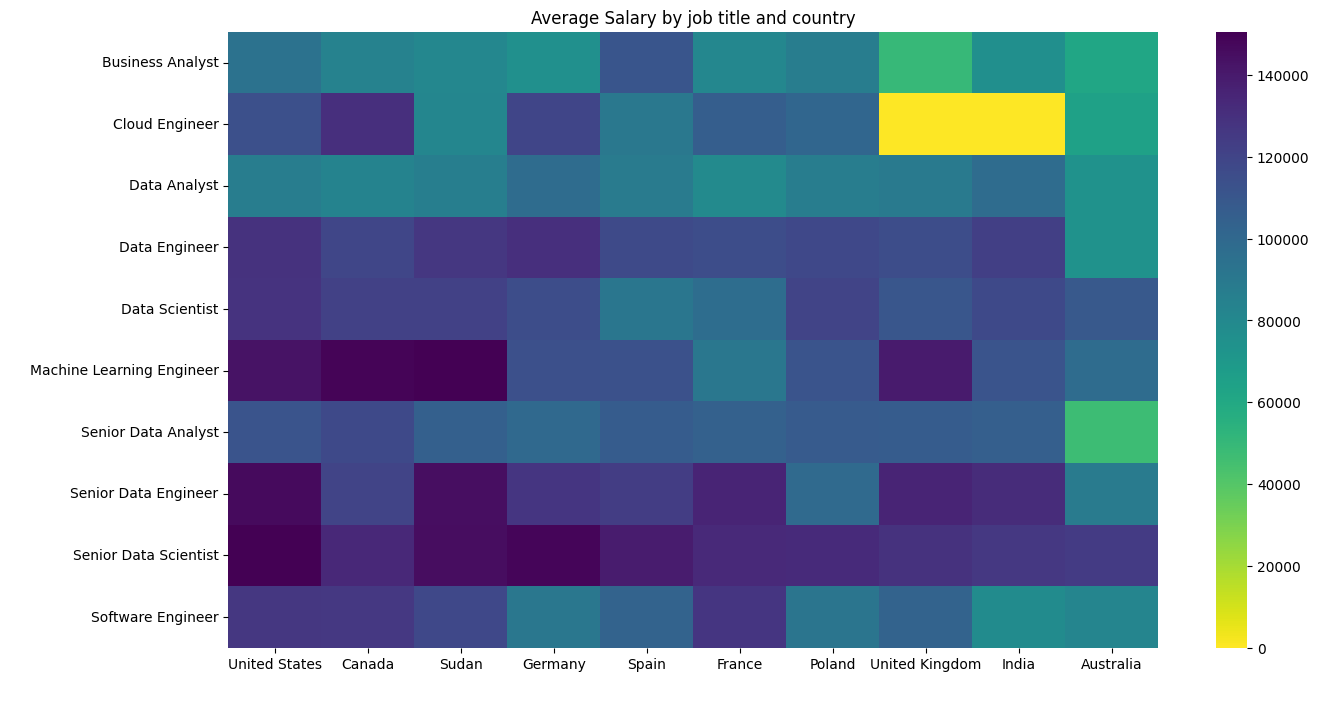

In [39]:
plt.figure(figsize=(15,8))
sns.heatmap(salary_pivot, cmap="viridis_r")
plt.title("Average Salary by job title and country")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()